In [1]:
!pip install sklearn scikit-learn


[notice] A new release of pip is available: 23.2.1 -> 25.2
[notice] To update, run: pip install --upgrade pip


In [2]:
import pandas as pd

# Read Reddit Data
reddit_comments = pd.read_csv("redditcomments.csv")
reddit_comments = reddit_comments.rename(columns={"cleaned_text": "processed_text", "comment": "text"})
yt_comments = pd.read_excel("method-1-youtube/scripts/youtube_comments.xlsx", sheet_name="youtube_base")
comments = pd.concat([reddit_comments, yt_comments])
comments

,Unnamed: 0,url,text,processed_text,title,link,date_published,like_count,reply_parent_id
0,0.0,https://www.reddit.com/r/Office365/comments/yl...,"Same here, updated after Word was acting ""funn...",here updat word wa act funny ms e win h appear...,NaN,NaN,NaN,NaN,NaN
1,1.0,https://www.reddit.com/r/Office365/comments/yl...,Ok so I came across this today when I went to ...,ok came across thi today went add process vpn ...,NaN,NaN,NaN,NaN,NaN
2,2.0,https://www.reddit.com/r/Office365/comments/yl...,ai.exe: The executable used to host ai.dll. T...,ai exe execut use host ai dll thi execut recei...,NaN,NaN,NaN,NaN,NaN
3,3.0,https://www.reddit.com/r/Office365/comments/yl...,I deleted the following folder to fix the prob...,delet follow folder fix problem c program file...,NaN,NaN,NaN,NaN,NaN
4,4.0,https://www.reddit.com/r/Office365/comments/yl...,"hey kids, do this, you run one chat gpt from t...",hey kids this run one chat gpt darkweb run ano...,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...
1558,NaN,NaN,It is non living things thats what makes it da...,NaN,It is non living things thats what makes it da...,https://www.youtube.com/watch?v=Klo55E1WJCk&lc...,2025-07-13T01:26:24Z,4.0,Ugyyo9rOjhlIycll2th4AaABAg
1559,NaN,NaN,​@@RC_Edits0you sounded all cool saying that b...,NaN,​@@RC_Edits0you sounded all cool saying that b...,https://www.youtube.com/watch?v=Klo55E1WJCk&lc...,2025-07-13T01:57:50Z,2.0,Ugyyo9rOjhlIycll2th4AaABAg
1560,NaN,NaN,​@@asura9343 what if we give him all of emotio...,NaN,​@@asura9343 what if we give him all of emotio...,https://www.youtube.com/watch?v=Klo55E1WJCk&lc...,2025-07-13T02:02:29Z,0.0,Ugyyo9rOjhlIycll2th4AaABAg
1561,NaN,NaN,​​@@RC_Edits0 exactly but tell me who in their...,NaN,​​@@RC_Edits0 exactly but tell me who in their...,https://www.youtube.com/watch?v=Klo55E1WJCk&lc...,2025-07-13T02:13:27Z,0.0,Ugyyo9rOjhlIycll2th4AaABAg


count    1747.000000
mean      139.522610
std       255.070796
min         1.000000
25%        34.500000
50%        71.000000
75%       156.000000
max      4591.000000
Name: text, dtype: float64
count     1563.000000
mean       207.128599
std       1203.933796
min          0.000000
25%          0.000000
50%          3.000000
75%         16.500000
max      22550.000000
Name: like_count, dtype: float64
text
Hello! You got it right. The correct answer is Option C) To program an intelligent machine. The goal of Artificial intelligence is to create which can think and act intelligently like a human.                                                                                                                                                                                                                                                                                                                                                                                                               

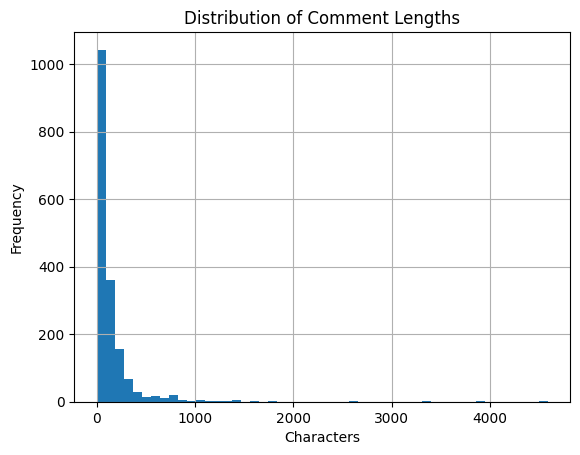

[nltk_data] Downloading package stopwords to
[nltk_data]     /home/julyanna/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Topic 0:
['nhi', 'bro', 'ho', 'hi', 'india', 'bhai', 'se', 'bhi', 'ki', 'hai']
---
Topic 1:
['understand', 'feel', 'day', 'earth', 'robot', 'movie', 'way', 'need', 'years', 'like']
---
Topic 2:
['time', 'think', 'dont', 'like', 'im', 'good', 'thats', 'going', 'people', 'ai']
---
Topic 3:
['artificial', 'think', 'human', 'course', 'video', 'really', 'machine', 'intelligence', 'learning', 'ai']
---
Topic 4:
['intelligence', 'right', 'emotions', 'thanks', 'channel', 'option', 'machine', 'video', 'ai', 'answer']
---


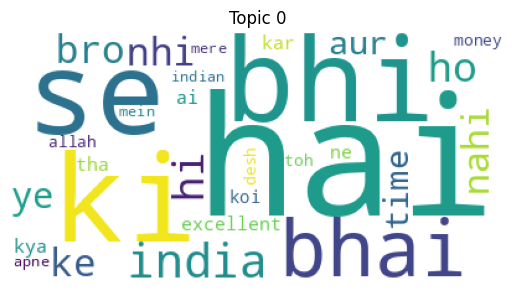

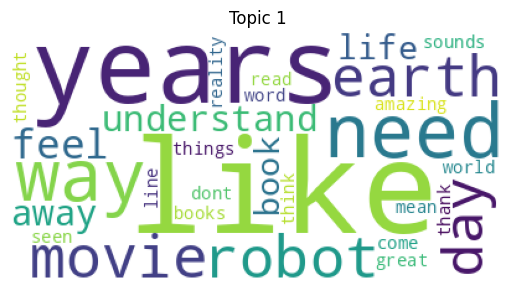

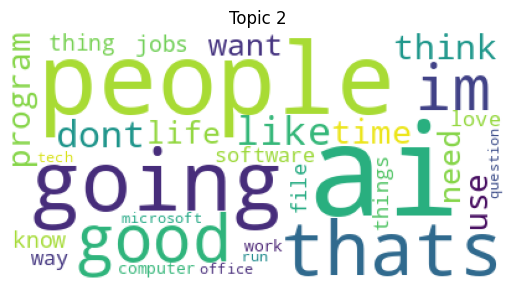

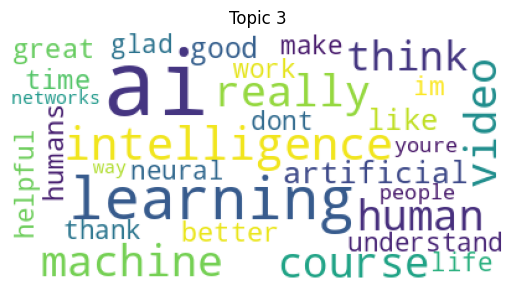

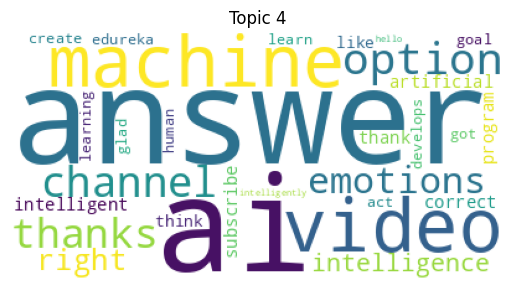

In [3]:
# Load Data
import pandas as pd

# Exploratory Data Analysis
# basic stats
print(comments['text'].str.len().describe())
print(yt_comments['like_count'].describe())

# Most common comments
print(comments['text'].value_counts().head(10))

# distribution of comment lengths
import matplotlib.pyplot as plt
comments['text'].str.len().hist(bins=50)
plt.title("Distribution of Comment Lengths")
plt.xlabel("Characters")
plt.ylabel("Frequency")
plt.show()

# nlp Preprocessing
import re
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')

tagalog_stop_words = ["akin","aking","ako","alin","am","amin","aming","ang","ano","anumang","apat","at","atin","ating","ay","bababa","bago","bakit","bawat","bilang","dahil","dalawa","dapat","din","dito","doon","gagawin","gayunman","ginagawa","ginawa","ginawang","gumawa","gusto","habang","hanggang","hindi","huwag","iba","ibaba","ibabaw","ibig","ikaw","ilagay","ilalim","ilan","inyong","isa","isang","itaas","ito","iyo","iyon","iyong","ka","kahit","kailangan","kailanman","kami","kanila","kanilang","kanino","kanya","kanyang","kapag","kapwa","karamihan","katiyakan","katulad","kaya","kaysa","ko","kong","kulang","kumuha","kung","laban","lahat","lamang","likod","lima","maaari","maaaring","maging","mahusay","makita","marami","marapat","masyado","may","mayroon","mga","minsan","mismo","mula","muli","na","nabanggit","naging","nagkaroon","nais","nakita","namin","napaka","narito","nasaan","ng","ngayon","ni","nila","nilang","nito","niya","niyang","noon","o","pa","paano","pababa","paggawa","pagitan","pagkakaroon","pagkatapos","palabas","pamamagitan","panahon","pangalawa","para","paraan","pareho","pataas","pero","pumunta","pumupunta","sa","saan","sabi","sabihin","sarili","sila","sino","siya","tatlo","tayo","tulad","tungkol","una","walang"]
stop_words = set(stopwords.words('english')) | set(tagalog_stop_words)

def clean_text(text):
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = re.sub(r'http\S+', '', text)      # remove links
    text = re.sub(r'[^a-z\s]', '', text)     # keep only letters
    words = [w for w in text.split() if w not in stop_words]
    return " ".join(words)

comments['processed_text'] = comments['text'].apply(clean_text)
comments[['text','processed_text']].head()

# Topic Modeling
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

# vectorize
vectorizer = CountVectorizer(max_df=0.95, min_df=2, stop_words='english')
X = vectorizer.fit_transform(comments['processed_text'])

# fit LDA
lda = LatentDirichletAllocation(n_components=5, random_state=42)
lda.fit(X)

# print top words per topic
terms = vectorizer.get_feature_names_out()
for idx, topic in enumerate(lda.components_):
    print(f"Topic {idx}:")
    print([terms[i] for i in topic.argsort()[-10:]])
    print("---")

# visualize topics with word clouds
from wordcloud import WordCloud

for idx, topic in enumerate(lda.components_):
    plt.figure()
    plt.imshow(WordCloud(background_color='white').fit_words({terms[i]: topic[i] for i in topic.argsort()[-30:]}))
    plt.axis("off")
    plt.title(f"Topic {idx}")
    plt.savefig(f"topic{idx}.png")

# Assign Topics to Comments
comment_topics = lda.transform(X).argmax(axis=1)
comments['topic'] = comment_topics
comments[['text','topic']].head(20)

# Save results
comments.to_excel("comments_with_topics.xlsx", index=False)
comments.to_csv("comments_with_topics.csv", index=False)

## Exploratory data Analysis
- Number of comments: 3043
- distribution of lengths is skewed (most under 200 characters)
- Most common words include political names (Risa (hontiveros), Raffy (tulfo), etc.)

## Topic Modeling Results
- Topic 0: Support for Risa Hontiveros
- Topic 1: Criticism & comparisons with other senators
- Topic 2: Conversational fillers in tagalog
- Topic 3: political commentary in general
- Topic 4: Mentions of senators (Chiz, Marcoleta, etc.)


In [4]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
import pyLDAvis
import numpy as np
from nrclex import NRCLex

In [5]:
vectorizer = CountVectorizer(max_df=0.95, min_df=2, stop_words='english')
doc_term_matrix=vectorizer.fit_transform(comments['processed_text'])

In [6]:
topic_term_matrix = lda.components_
doc_topic_matrix = lda.transform(doc_term_matrix)

In [7]:
vocab = vectorizer.get_feature_names_out()
doc_lengths = [len(doc) for doc in comments['processed_text']]
term_freqs = doc_term_matrix.sum(axis=0)
term_freqs = np.array(term_freqs).flatten()
vis_data = pyLDAvis.prepare(topic_term_matrix, doc_topic_matrix, doc_lengths, vocab, term_freqs)

pyLDAvis.display(vis_data)

In [8]:
from nltk.sentiment import SentimentIntensityAnalyzer
nltk.download(["vader_lexicon"])

senti = SentimentIntensityAnalyzer()

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     /home/julyanna/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


In [9]:
def sentiment_analysis(dataframe, textcolumn):
    for index, row in dataframe.iterrows():
        senti_score = senti.polarity_scores(str(row[textcolumn]))
        dataframe.loc[index, 'neg'] = senti_score['neg']
        dataframe.loc[index, 'neu'] = senti_score['neu']
        dataframe.loc[index, 'pos'] = senti_score['pos']
        dataframe.loc[index, 'compound'] = senti_score['compound']
    return dataframe

In [10]:
comment_sentiments = sentiment_analysis(comments, textcolumn='processed_text')

In [11]:
comment_sentiments[['text', 'neg', 'neu', 'pos', 'compound']]

,text,neg,neu,pos,compound
0,"Same here, updated after Word was acting ""funn...",0.000,0.636,0.364,0.7906
1,Ok so I came across this today when I went to ...,0.000,1.000,0.000,0.0000
2,ai.exe: The executable used to host ai.dll. T...,0.000,0.508,0.492,0.4404
3,I deleted the following folder to fix the prob...,0.000,0.580,0.420,0.8555
4,"hey kids, do this, you run one chat gpt from t...",0.149,0.851,0.000,-0.0572
...,...,...,...,...,...
1558,It is non living things thats what makes it da...,0.383,0.617,0.000,-0.4767
1559,​@@RC_Edits0you sounded all cool saying that b...,0.000,0.605,0.395,0.9140
1560,​@@asura9343 what if we give him all of emotio...,0.206,0.584,0.210,0.0258
1561,​​@@RC_Edits0 exactly but tell me who in their...,0.291,0.535,0.173,-0.6705


In [12]:
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /home/julyanna/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /home/julyanna/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [13]:
def affect_analysis(dataframe, textcolumn):
    for ix, row in dataframe.iterrows():
        text = str(row[textcolumn])
        text_obj = NRCLex(text)
        affect_dict = text_obj.affect_frequencies
        for key, val in affect_dict.items():
            dataframe.loc[ix, key] = val
    return dataframe

In [14]:
comment_affects = affect_analysis(comments, "processed_text")
comment_affects

,Unnamed: 0,url,text,processed_text,title,link,date_published,like_count,reply_parent_id,topic,...,anger,anticip,trust,surprise,positive,negative,sadness,disgust,joy,anticipation
0,0.0,https://www.reddit.com/r/Office365/comments/yl...,"Same here, updated after Word was acting ""funn...",updated word acting funny ms e win h appeared ...,NaN,NaN,NaN,NaN,NaN,2,...,0.000000,0.0,0.000000,0.000000,0.200000,0.000000,0.000000,0.000000,0.200000,0.400000
1,1.0,https://www.reddit.com/r/Office365/comments/yl...,Ok so I came across this today when I went to ...,ok came across today went add process vpn tunn...,NaN,NaN,NaN,NaN,NaN,2,...,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.052632
2,2.0,https://www.reddit.com/r/Office365/comments/yl...,ai.exe: The executable used to host ai.dll. T...,aiexe executable used host aidll executable re...,NaN,NaN,NaN,NaN,NaN,1,...,0.000000,0.0,0.333333,0.000000,0.333333,0.000000,0.000000,0.000000,0.333333,NaN
3,3.0,https://www.reddit.com/r/Office365/comments/yl...,I deleted the following folder to fix the prob...,deleted following folder fix problem cprogram ...,NaN,NaN,NaN,NaN,NaN,2,...,0.000000,0.0,0.272727,0.090909,0.363636,0.000000,0.000000,0.000000,0.181818,0.090909
4,4.0,https://www.reddit.com/r/Office365/comments/yl...,"hey kids, do this, you run one chat gpt from t...",hey kids run one chat gpt darkweb run another ...,NaN,NaN,NaN,NaN,NaN,2,...,0.000000,0.0,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.086957
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1558,NaN,NaN,It is non living things thats what makes it da...,non living things thats makes dangerous,It is non living things thats what makes it da...,https://www.youtube.com/watch?v=Klo55E1WJCk&lc...,2025-07-13T01:26:24Z,4.0,Ugyyo9rOjhlIycll2th4AaABAg,2,...,0.000000,0.0,0.000000,0.000000,0.000000,0.500000,0.000000,0.000000,0.000000,NaN
1559,NaN,NaN,​@@RC_Edits0you sounded all cool saying that b...,rceditsyou sounded cool saying honestly practi...,​@@RC_Edits0you sounded all cool saying that b...,https://www.youtube.com/watch?v=Klo55E1WJCk&lc...,2025-07-13T01:57:50Z,2.0,Ugyyo9rOjhlIycll2th4AaABAg,1,...,0.166667,0.0,0.166667,0.000000,0.333333,0.166667,0.000000,0.166667,0.000000,NaN
1560,NaN,NaN,​@@asura9343 what if we give him all of emotio...,asura give emotions like jealous happiness tel...,​@@asura9343 what if we give him all of emotio...,https://www.youtube.com/watch?v=Klo55E1WJCk&lc...,2025-07-13T02:02:29Z,0.0,Ugyyo9rOjhlIycll2th4AaABAg,1,...,0.125000,0.0,0.125000,0.000000,0.250000,0.125000,0.000000,0.062500,0.187500,0.062500
1561,NaN,NaN,​​@@RC_Edits0 exactly but tell me who in their...,rcedits exactly tell right mind would even wou...,​​@@RC_Edits0 exactly but tell me who in their...,https://www.youtube.com/watch?v=Klo55E1WJCk&lc...,2025-07-13T02:13:27Z,0.0,Ugyyo9rOjhlIycll2th4AaABAg,1,...,0.137931,0.0,0.103448,0.068966,0.103448,0.172414,0.034483,0.034483,0.068966,0.137931


In [15]:
comment_affects[['text', 'neu', 'positive', 'neg', 'compound', 'negative', 'disgust', 'surprise', 'joy', 'sadness', 'anger', 'fear', 'surprise', 'anticip']].describe()

,neu,positive,neg,compound,negative,disgust,surprise,joy,sadness,anger,fear,surprise,anticip
count,1747.000000,1747.000000,1747.000000,1747.000000,1747.000000,1747.000000,1747.000000,1747.000000,1747.000000,1747.000000,1747.000000,1747.000000,1747.0
mean,0.633994,0.228713,0.064582,0.250190,0.066029,0.014064,0.018958,0.067968,0.025962,0.022650,0.039573,0.018958,0.0
std,0.307509,0.287314,0.144243,0.449099,0.151575,0.049553,0.056454,0.106125,0.080789,0.067665,0.103994,0.056454,0.0
min,0.000000,0.000000,0.000000,-0.982100,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0
25%,0.425500,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0
50%,0.625000,0.150000,0.000000,0.051600,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0
75%,1.000000,0.333333,0.037000,0.636900,0.064583,0.000000,0.000000,0.142857,0.000000,0.000000,0.000000,0.000000,0.0
max,1.000000,1.000000,1.000000,0.992100,1.000000,0.500000,1.000000,0.500000,1.000000,1.000000,1.000000,1.000000,0.0
